In [ ]:
import time, shutil, itertools, pickle, warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.feature_extraction.text import TfidfVectorizer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('dataset.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [ ]:
print(f'The shape of the dataset is: {df.shape}')
print(f'The columns in the dataset are: {df.columns}')

df.drop('Unnamed: 0',axis=1,inplace =True)
df.reset_index(drop=True)
df.head()

The shape of the dataset is: (53043, 3)
The columns in the dataset are: Index(['Unnamed: 0', 'statement', 'status'], dtype='object')


,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


**EDA (Exploratory Data Analysis)**

In [ ]:
df.isna().sum()

,0
statement,362
status,0


In [ ]:
df.dropna(inplace = True)
df.isnull().sum()

,0
statement,0
status,0


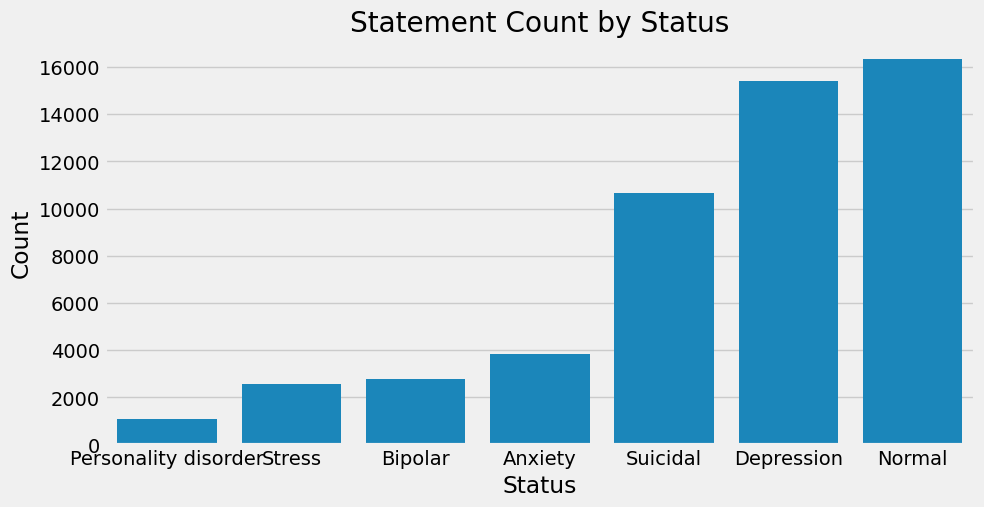

,statement,status
count,52681,52681
unique,51073,7
top,what do you mean?,Normal
freq,22,16343


In [ ]:
data = df.groupby('status')['statement'].count().sort_values().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=data, x='status', y='statement')
plt.xlabel('Status')
plt.ylabel('Count')
plt.title('Statement Count by Status')
plt.show()

df.describe()

In [ ]:
df['statement_length'] = df['statement'].apply(len)
df['num_words'] = df['statement'].apply(lambda x: len(x.split()))
df['avg_word_length'] = np.round(df['statement_length'] / df['num_words'])
df['avg_word_length'] = df['avg_word_length'].map(int)
df['vocabulary_size'] = df['statement'].apply(lambda x: len(set(x.split())))
df.head()

,statement,status,statement_length,num_words,avg_word_length,vocabulary_size
0,oh my gosh,Anxiety,10,3,3,3
1,"trouble sleeping, confused mind, restless hear...",Anxiety,64,10,6,10
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,78,14,6,13
3,I've shifted my focus to something else but I'...,Anxiety,61,11,6,11
4,"I'm restless and restless, it's been a month n...",Anxiety,72,14,5,14


In [ ]:
num_feature = [feature for feature in df.columns if df[feature].dtype != 'O']

num_feature

['statement_length', 'num_words', 'avg_word_length', 'vocabulary_size']

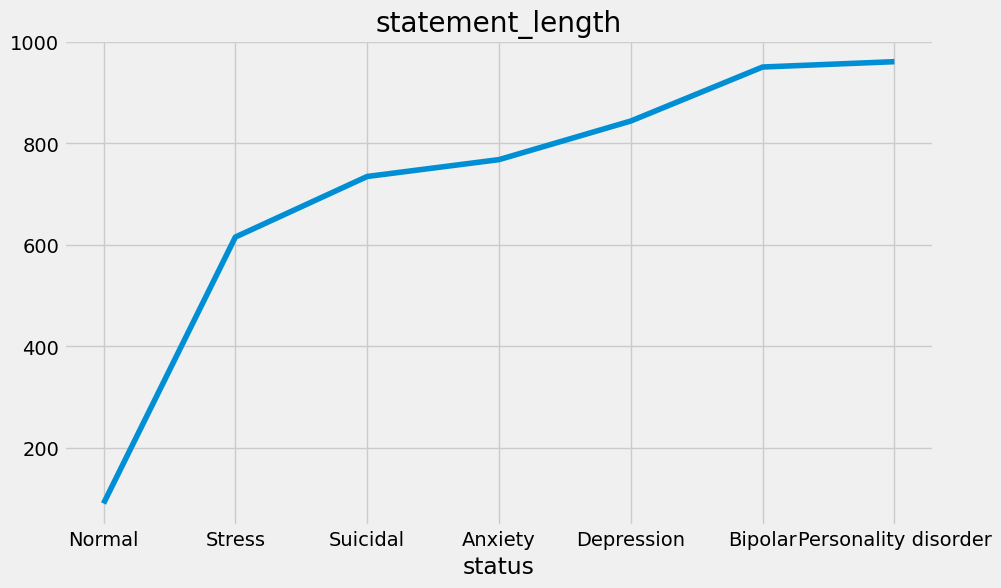

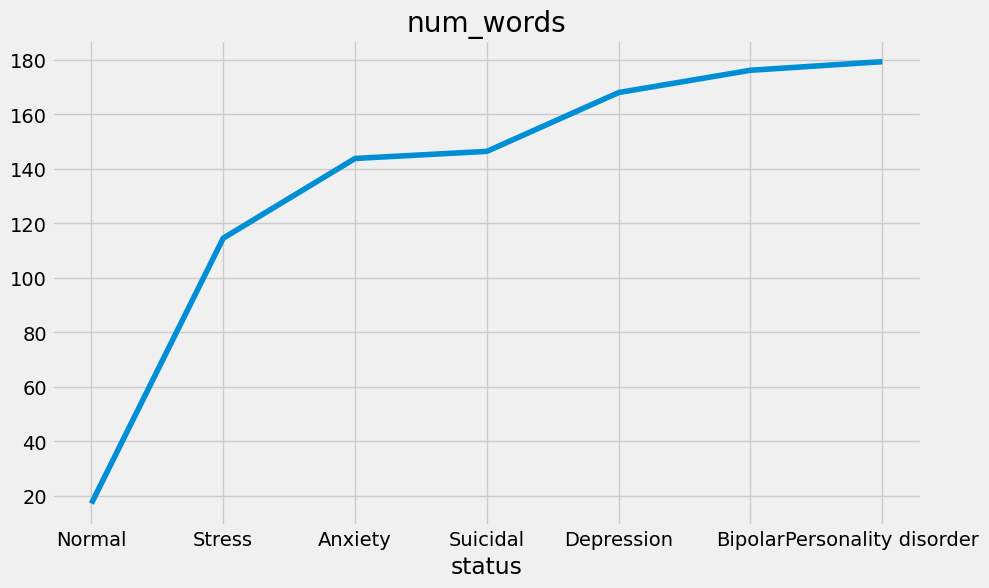

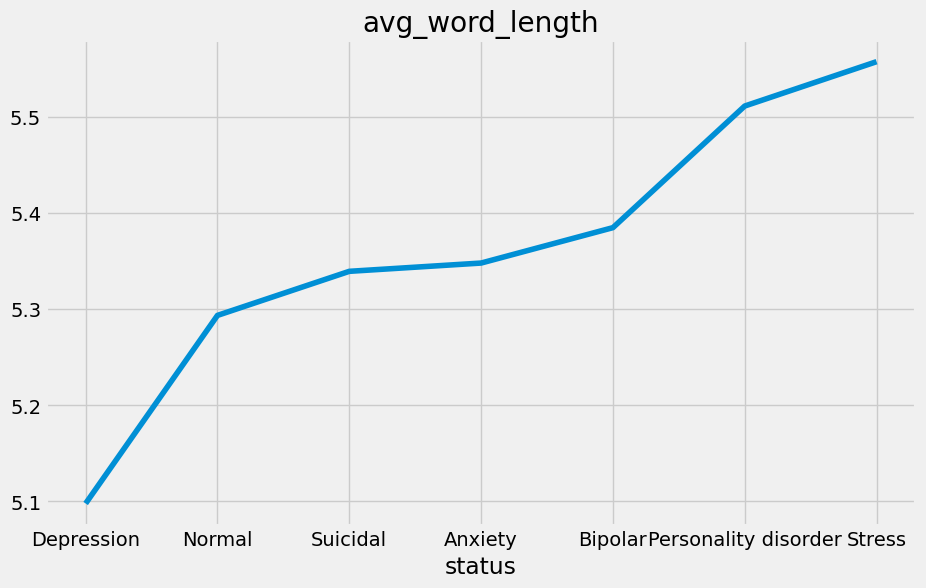

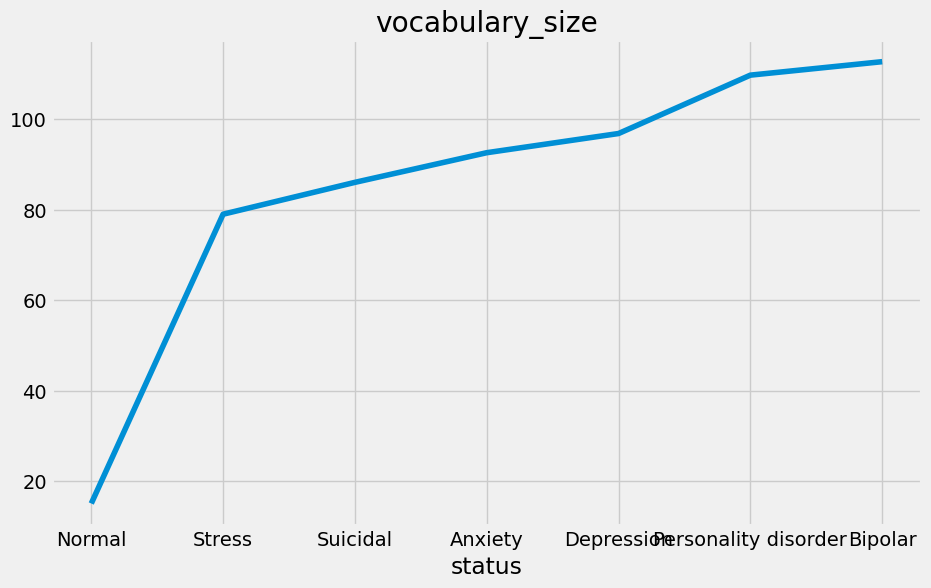

In [ ]:
for feature in num_feature:
    plt.figure(figsize= (10,6))
    df.groupby('status')[feature].mean().sort_values().plot()
    plt.title(feature)
    plt.show()

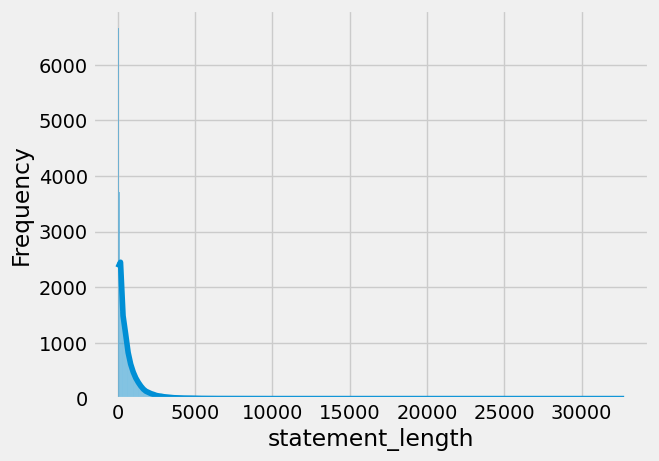

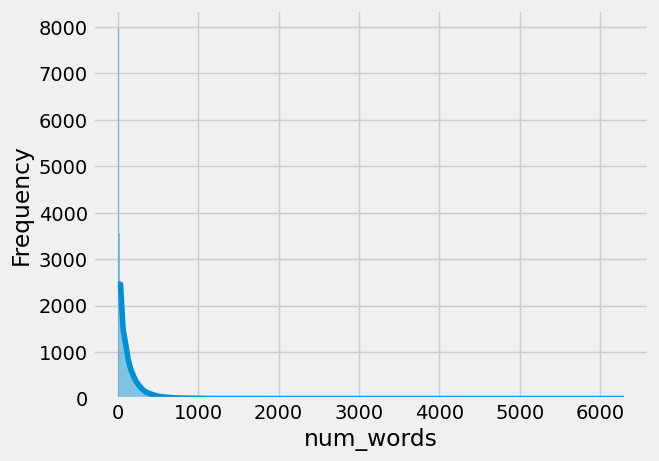

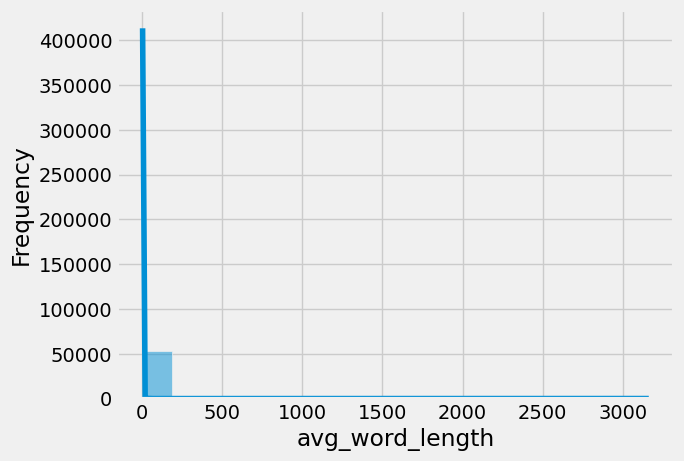

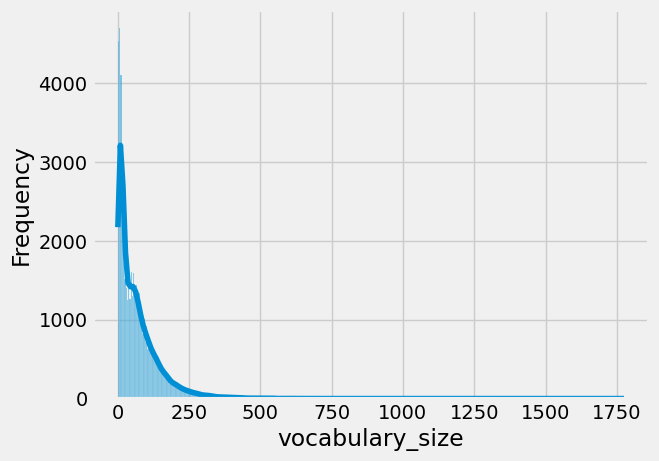

In [ ]:
for feature in num_feature:
    sns.histplot(data = df, x=feature,kde=True)
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

# Data Is Heavily Skewed To the Right.. Will Apply Log Function In The Preprocessing Step To Solve This.

**Preprocessing**

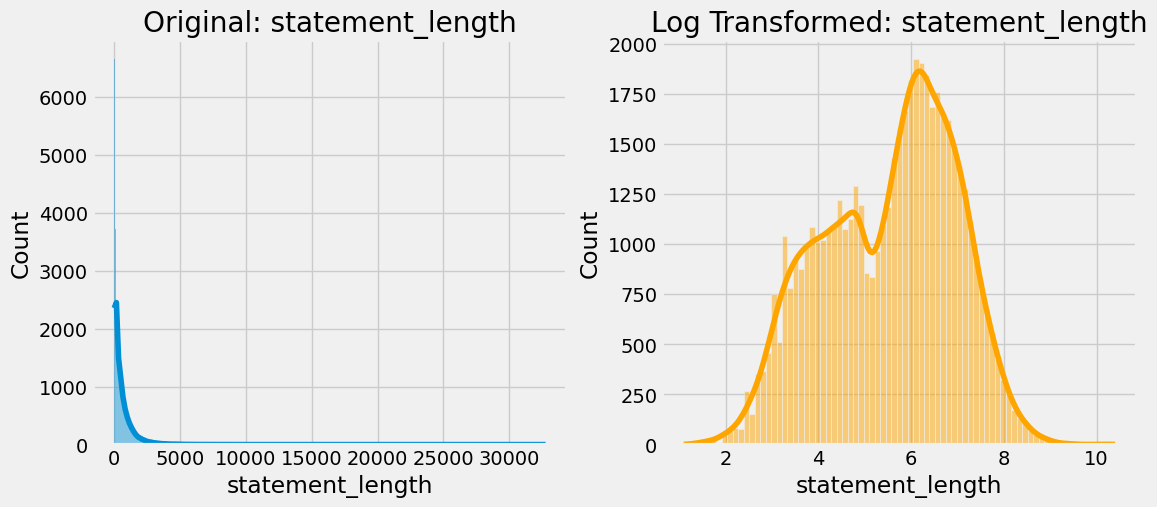

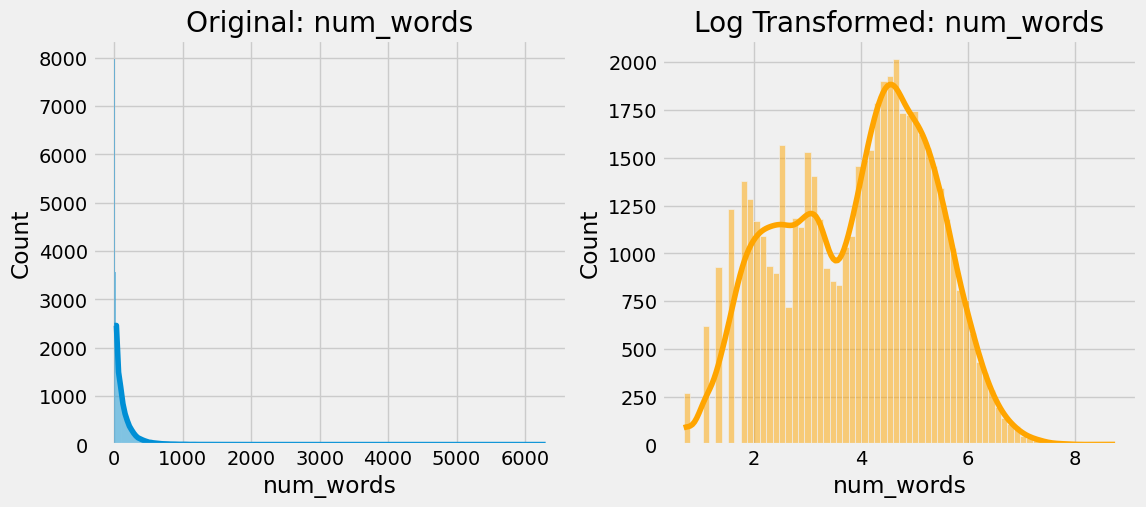

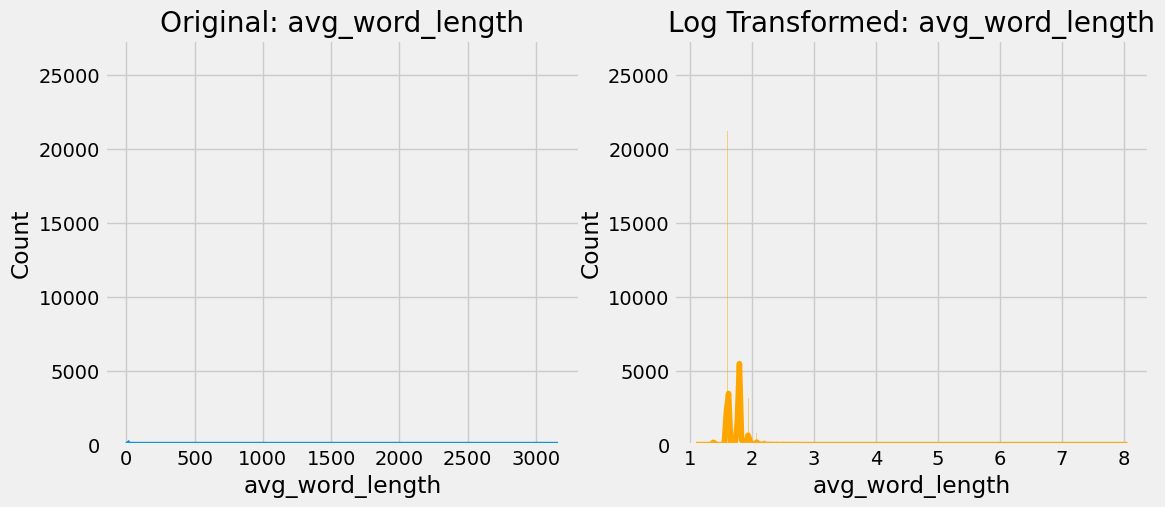

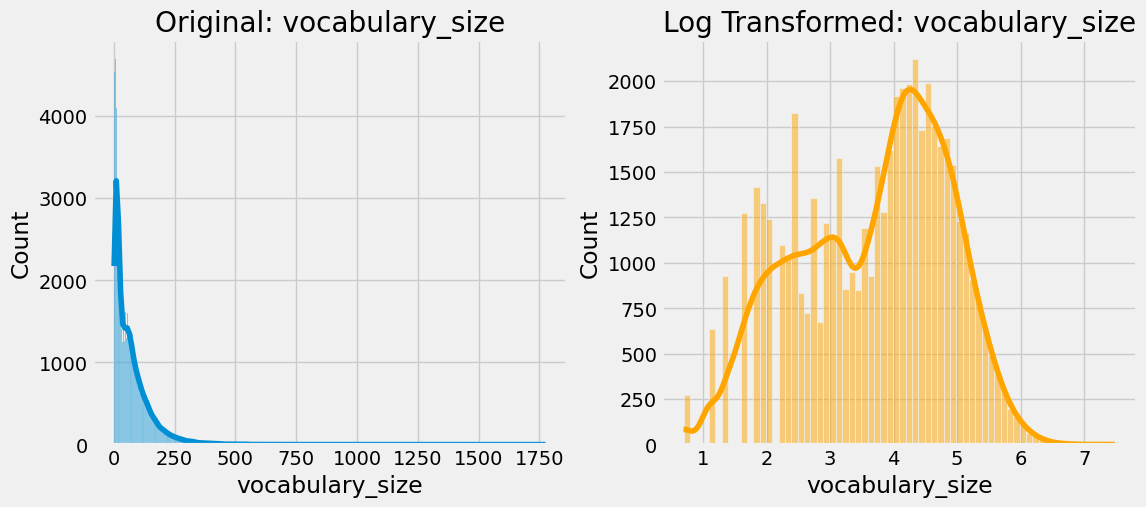

In [ ]:
df['statement_length'] = df['statement'].apply(len)
df['num_words'] = df['statement'].apply(lambda x: len(x.split()))
df['vocabulary_size'] = df['statement'].apply(lambda x: len(set(x.split())))

df['avg_word_length'] = (df['statement_length'] / df['num_words']).replace(np.inf, 0).fillna(0).astype(int)
num_feature = ['statement_length', 'num_words', 'avg_word_length', 'vocabulary_size']

df['statement'] = df['statement'].apply(lambda x: " ".join(x.lower().split()))

for feature in num_feature:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x=feature, kde=True)
    plt.title(f'Original: {feature}')

    log_data = np.log1p(df[feature])

    plt.subplot(1, 2, 2)
    sns.histplot(x=log_data, kde=True, color='orange')
    plt.title(f'Log Transformed: {feature}')

    plt.show()

In [ ]:
# Label Encoding
label_ordered = df['status'].value_counts().index
label_map = {k: i for i, k in enumerate(label_ordered)}
df['status'] = df['status'].map(label_map)

print(f"Label Mapping: {label_map}")

Label Mapping: {'Normal': 0, 'Depression': 1, 'Suicidal': 2, 'Anxiety': 3, 'Bipolar': 4, 'Stress': 5, 'Personality disorder': 6}


<Axes: >

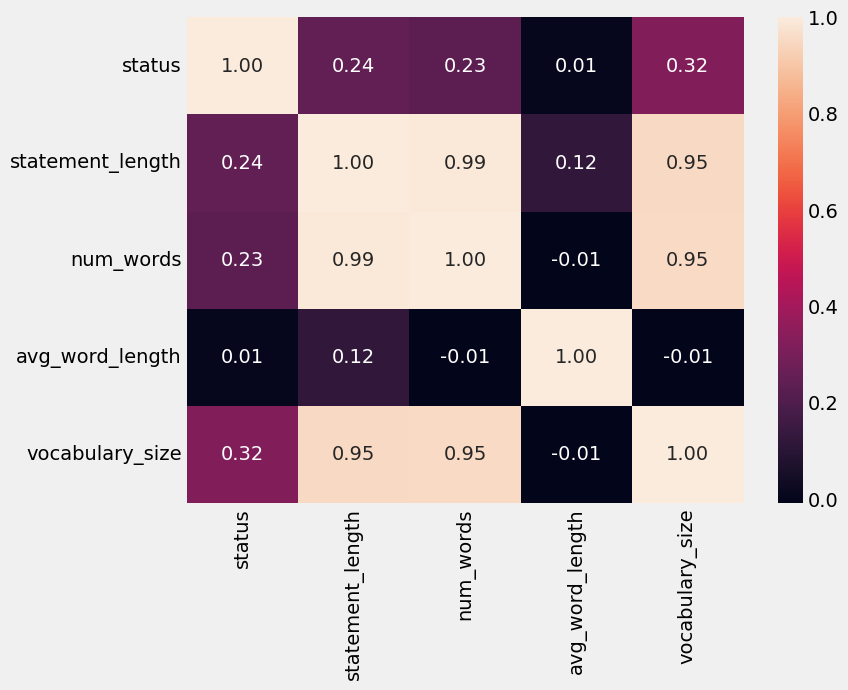

In [ ]:
Heatmap = df[['status','statement_length','num_words','avg_word_length','vocabulary_size']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(Heatmap,annot=True, fmt=".2f")

In [ ]:
df['status'].value_counts()

,count
status,
0,16343
1,15404
2,10652
3,3841
4,2777
5,2587
6,1077


NEW

In [ ]:
X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(
    df['statement'], df['status'],
    test_size=0.2,
    random_state=42,
    stratify=df['status']
)

X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"Original Shape -> Train: {X_train_raw.shape}, Val: {X_val_raw.shape}, Test: {X_test_raw.shape}")

Original Shape -> Train: (42144,), Val: (5268,), Test: (5269,)


In [ ]:
train_df = pd.concat([X_train_raw, y_train_raw], axis=1)

majority_class = train_df['status'].value_counts().idxmax()
majority_count = train_df['status'].value_counts().max()

train_dfs_balanced = []

for status_val in train_df['status'].unique():
    subset = train_df[train_df['status'] == status_val]

    if status_val == majority_class:
        train_dfs_balanced.append(subset)
    else:
        resampled_subset = resample(subset,
                                    replace=True,
                                    n_samples=majority_count,
                                    random_state=42)
        train_dfs_balanced.append(resampled_subset)

train_df_balanced = pd.concat(train_dfs_balanced).sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced Training Distribution:")
print(train_df_balanced['status'].value_counts())

X_train_final = train_df_balanced['statement']
y_train_final = train_df_balanced['status']

Balanced Training Distribution:
status
1    13074
2    13074
0    13074
5    13074
4    13074
6    13074
3    13074
Name: count, dtype: int64


In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train_final)
maxlen = 500
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_final), maxlen=maxlen)
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val_raw), maxlen=maxlen)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test_raw), maxlen=maxlen)

y_train_seq = np.array(y_train_final)
y_val_seq = np.array(y_val_raw)
y_test_seq = np.array(y_test_raw)

word_counts = len(tokenizer.word_index) + 1
word_counts

51445

In [ ]:
# Define a class for custom callback
class MyCallback(keras.callbacks.Callback):
    def __init__(self, patience, stop_patience, threshold, factor, initial_epoch, epochs, ask_epoch):
        super(MyCallback, self).__init__()
        self.patience = patience  # epochs without improvement before adjusting lr
        self.stop_patience = stop_patience  # times to adjust lr without improvement before stopping
        self.threshold = threshold  # training accuracy threshold
        self.factor = factor  # factor to reduce lr
        self.initial_epoch = initial_epoch
        self.epochs = epochs
        self.ask_epoch = ask_epoch
        self.ask_epoch_initial = ask_epoch  # save initial ask_epoch

        # Callback variables
        self.count = 0
        self.stop_count = 0
        self.best_epoch = 1
        self.initial_lr = None
        self.highest_tracc = 0.0
        self.lowest_vloss = np.inf
        self.best_weights = None
        self.initial_weights = None

    # Called when training begins
    def on_train_begin(self, logs=None):
        self.initial_lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        self.best_weights = self.model.get_weights()  # safe now
        self.initial_weights = self.model.get_weights()
        msg = '{0:^8s}{1:^10s}{2:^9s}{3:^9s}{4:^9s}{5:^9s}{6:^9s}{7:^10s}{8:10s}{9:^8s}'.format('Epoch', 'Loss', 'Accuracy', 'V_loss', 'V_acc', 'LR', 'Next LR', 'Monitor','% Improv', 'Duration')
        print(msg)
        self.start_time = time.time()

    # Called when training ends
    def on_train_end(self, logs=None):
        stop_time = time.time()
        tr_duration = stop_time - self.start_time
        hours = tr_duration // 3600
        minutes = (tr_duration - (hours * 3600)) // 60
        seconds = tr_duration - ((hours * 3600) + (minutes * 60))
        msg = f'Training elapsed time was {int(hours)} hours, {minutes:4.1f} minutes, {seconds:4.2f} seconds'
        print(msg)
        self.model.set_weights(self.best_weights)  # restore best weights

    # Called at the end of each batch
    def on_train_batch_end(self, batch, logs=None):
        acc = logs.get('accuracy') * 100
        loss = logs.get('loss')


    # Called at the beginning of each epoch
    def on_epoch_begin(self, epoch, logs=None):
        self.ep_start = time.time()

    # Called at the end of each epoch
    def on_epoch_end(self, epoch, logs=None):
        ep_end = time.time()
        duration = ep_end - self.ep_start

        lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        current_lr = lr

        acc = logs.get('accuracy')
        v_acc = logs.get('val_accuracy')
        loss = logs.get('loss')
        v_loss = logs.get('val_loss')

        if acc < self.threshold:
            monitor = 'accuracy'
            pimprov = 0.0 if epoch == 0 else (acc - self.highest_tracc) * 100 / self.highest_tracc

            if acc > self.highest_tracc:
                self.highest_tracc = acc
                self.best_weights = self.model.get_weights()
                self.count = 0
                self.stop_count = 0
                if v_loss < self.lowest_vloss:
                    self.lowest_vloss = v_loss
                self.best_epoch = epoch + 1
            else:
                if self.count >= self.patience - 1:
                    lr = lr * self.factor
                    self.model.optimizer.learning_rate.assign(lr)
                    self.count = 0
                    self.stop_count += 1
                    if v_loss < self.lowest_vloss:
                        self.lowest_vloss = v_loss
                else:
                    self.count += 1
        else:
            monitor = 'val_loss'
            pimprov = 0.0 if epoch == 0 else (self.lowest_vloss - v_loss) * 100 / self.lowest_vloss

            if v_loss < self.lowest_vloss:
                self.lowest_vloss = v_loss
                self.best_weights = self.model.get_weights()
                self.count = 0
                self.stop_count = 0
                self.best_epoch = epoch + 1
            else:
                if self.count >= self.patience - 1:
                    lr = lr * self.factor
                    self.model.optimizer.learning_rate.assign(lr)
                    self.stop_count += 1
                    self.count = 0
                else:
                    self.count += 1
                if acc > self.highest_tracc:
                    self.highest_tracc = acc

        msg = f'{epoch + 1:^3}/{self.epochs:^4} {loss:^9.3f}{acc*100:^9.3f}{v_loss:^9.5f}{v_acc*100:^9.3f}{current_lr:^9.5f}{lr:^9.5f}{monitor:^11}{pimprov:^10.2f}{duration:^8.2f}'
        print(msg)

        if self.stop_count > self.stop_patience - 1:
            msg = f'Training halted at epoch {epoch + 1} after {self.stop_patience} adjustments with no improvement'
            print(msg)
            self.model.stop_training = True
        elif self.ask_epoch is not None and epoch + 1 >= self.ask_epoch:
            msg = 'Enter H to halt training or an integer for number of epochs to run then ask again'
            print(msg)
            ans = input('')
            if ans.lower() == 'h':
                msg = f'Training halted at epoch {epoch + 1} by user input'
                print(msg)
                self.model.stop_training = True
            else:
                try:
                    ans = int(ans)
                    self.ask_epoch += ans
                    msg = f'Training will continue until epoch {self.ask_epoch}'
                    print(msg)
                    header = '{0:^8s}{1:^10s}{2:^9s}{3:^9s}{4:^9s}{5:^9s}{6:^9s}{7:^10s}{8:10s}{9:^8s}'.format(
                        'Epoch', 'Loss', 'Accuracy', 'V_loss', 'V_acc', 'LR', 'Next LR', 'Monitor', '% Improv', 'Duration'
                    )
                    print(header)
                except:
                    print('Invalid input')

In [ ]:
model = Sequential([
    Embedding(word_counts, 300, input_length=maxlen),

    tf.keras.layers.SpatialDropout1D(0.3),
    tf.keras.layers.Bidirectional(LSTM(128, return_sequences=True, kernel_regularizer=regularizers.l2(1e-4))),

    LSTM(64, return_sequences=False, kernel_regularizer=regularizers.l2(1e-4)),

    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

batch_size = 128
epochs = 40
patience = 2
stop_patience = 3
threshold = 0.9
factor = 0.1
ask_epoch = None


callbacks = [MyCallback(patience= patience,
            stop_patience= stop_patience, threshold= threshold, factor= factor
            ,initial_epoch= 0, epochs= epochs, ask_epoch= ask_epoch )]

model.compile(optimizer=Adamax(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    # X_train, y_train,
    # validation_data=(X_valid, y_valid),
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=epochs,
    callbacks=callbacks,
    batch_size=batch_size,
    initial_epoch=0
)

 Epoch     Loss   Accuracy  V_loss    V_acc     LR     Next LR  Monitor  % Improv  Duration
Epoch 1/40
715/715 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.3730 - loss: 1.5726 1 / 40    1.323   47.732   0.92684  62.149   0.00100  0.00100  accuracy     0.00    104.26 
715/715 ━━━━━━━━━━━━━━━━━━━━ 104s 140ms/step - accuracy: 0.3731 - loss: 1.5722 - val_accuracy: 0.6215 - val_loss: 0.9268
Epoch 2/40
715/715 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.7132 - loss: 0.8239 2 / 40    0.745   74.413   0.80718  68.603   0.00100  0.00100  accuracy    55.90    99.67  
715/715 ━━━━━━━━━━━━━━━━━━━━ 100s 139ms/step - accuracy: 0.7133 - loss: 0.8238 - val_accuracy: 0.6860 - val_loss: 0.8072
Epoch 3/40
715/715 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.8102 - loss: 0.5792 3 / 40    0.537   82.450   0.76456  72.836   0.00100  0.00100  accuracy    10.80    99.61  
715/715 ━━━━━━━━━━━━━━━━━━━━ 100s 139ms/step - accuracy: 0.8102 - loss: 0.5792 - val_accuracy: 0.7284 - val_loss: 0.7646
Epoch

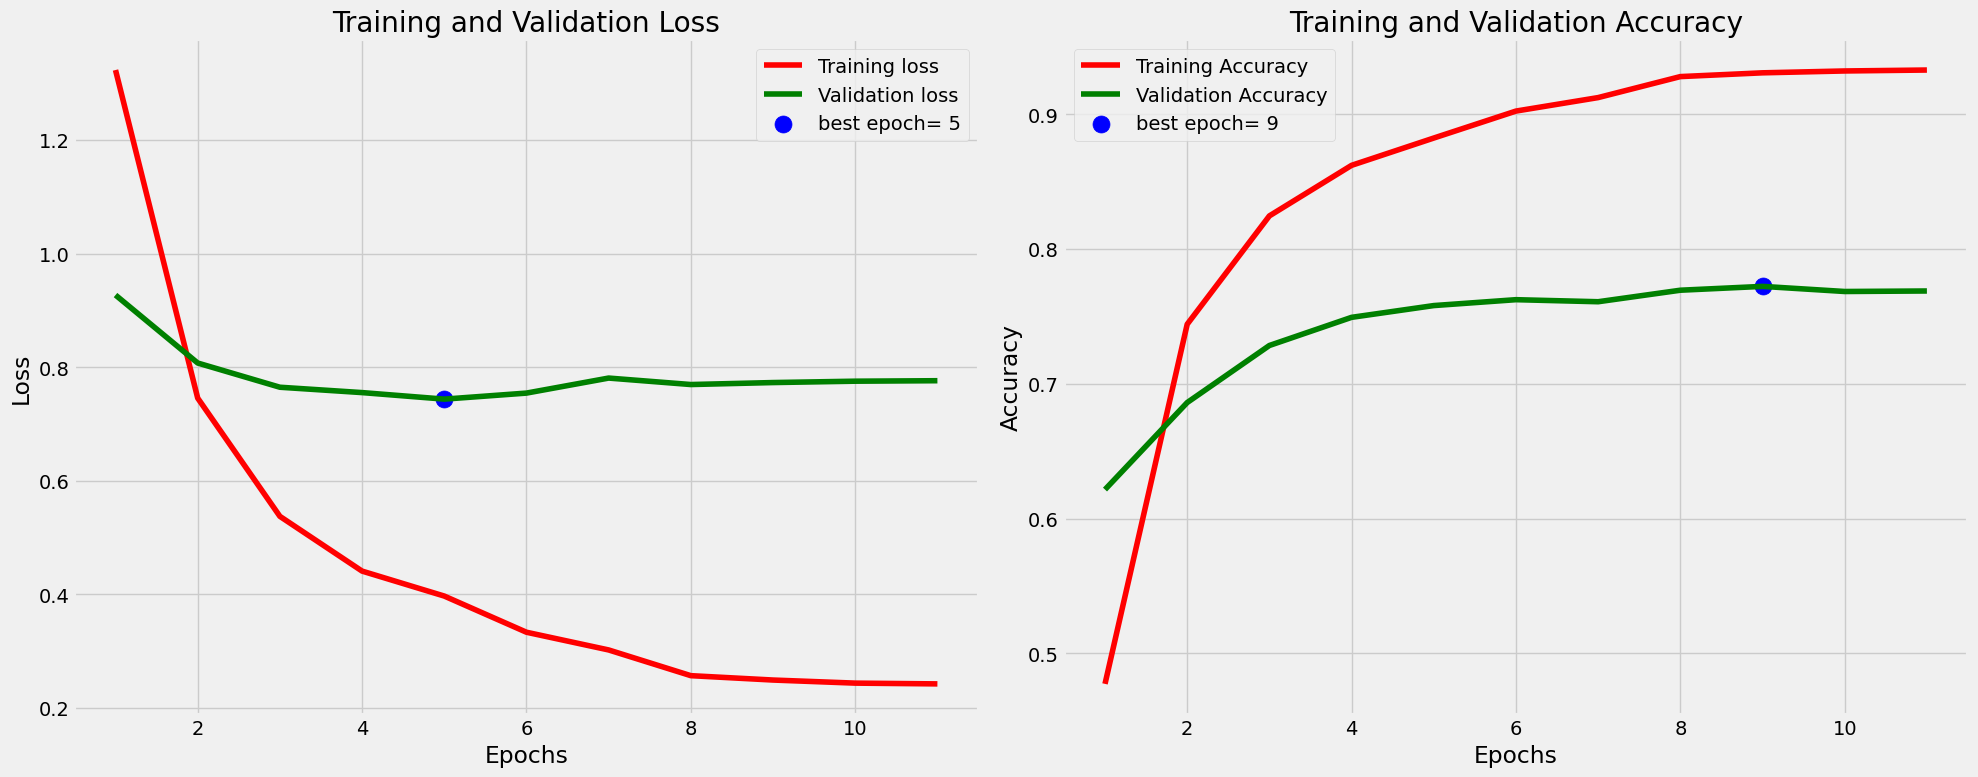

In [ ]:
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('model_evaluation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
test_loss, test_acc = model.evaluate(X_test_seq, y_test_seq, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7475 - loss: 0.7642
Test Loss: 0.7726
Test Accuracy: 0.7461


In [ ]:
# y_pred_prob = model.predict(X_test)
# y_pred = np.argmax(y_pred_prob, axis=1)
# print("Classification Report:\n")
# print(classification_report(y_test, y_pred))

y_pred_prob = model.predict(X_test_seq)
y_pred = np.argmax(y_pred_prob, axis=1)
print("Classification Report:\n")
print(classification_report(y_test_seq, y_pred))

165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.90      0.92      1635
           1       0.76      0.58      0.65      1541
           2       0.61      0.77      0.68      1066
           3       0.80      0.74      0.77       384
           4       0.69      0.80      0.74       278
           5       0.44      0.67      0.53       258
           6       0.63      0.68      0.66       107

    accuracy                           0.75      5269
   macro avg       0.70      0.73      0.71      5269
weighted avg       0.77      0.75      0.75      5269



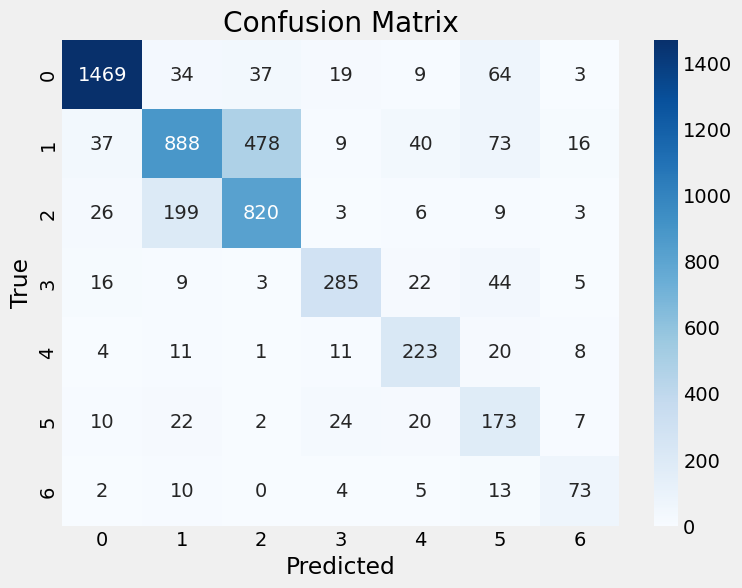

In [ ]:
plt.figure(figsize=(8,6))

# cm = confusion_matrix(y_test, y_pred)
cm = confusion_matrix(y_test_seq, y_pred)


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

**Model Test (Using Random Data in Dataset)**

In [ ]:
print(df.iloc[5123])


statement           love is never wrong and love never hurts. #bel...
status                                                              0
statement_length                                                   71
num_words                                                          13
avg_word_length                                                     5
vocabulary_size                                                    11
Name: 5131, dtype: object


In [ ]:
sample = df['statement'].iloc[5123]
def predict_text(text):
    seq = tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=500)

    pred = model.predict(seq)
    label = np.argmax(pred)

    print(f"Predicted label: {label}")

predict_text(sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted label: 0


In [ ]:
model.save("lstm_suicidal_nlp.h5")
print("Model saved")

Model saved


**Model Test (Using New Data)**

In [ ]:
test_data = [
    ("I can't sleep at night and my thoughts won't stop racing.", 'Anxiety'),
    ("Lately, I've been feeling so numb and disconnected from everything.", 'Depression'),
    ("Everything feels fine, just a normal day with coffee and work.", 'Normal'),
    ("I'm afraid to go outside. The world feels overwhelming.", 'Anxiety'),
    ("Sometimes I feel like ending it all. What's the point?", 'Suicidal'),
    ("I’m trying to stay strong, but my mood swings are exhausting.", 'Bipolar'),
    ("I'm confident, happy, and ready to face the day!", 'Normal'),
    ("My mind jumps from one idea to another. I can’t stay still.", 'Bipolar'),
    ("I don’t even recognize myself anymore. Who am I becoming?", 'Personality disorder'),
    ("Feeling a bit stressed, but I think I can manage it with deep breaths.", 'Stress'),
    ("It ends tonight.I can’t do it anymore. I quit.", 'Suicidal'),
    ("Is it worth it?Is all the trouble, work and anxiety really worth living for.", 'Suicidal'),
    ("do you ever feel empty and you had to pick a number from 15 depending how you feel about it i could write my funeral speech now but what is the point in afew years i would be forgotten anyway", 'Suicidal'),
    ("How painful is it and what are the chances of dying from it", 'Suicidal'),
    ("I heard from my therapist that anger and depression often go hand in hand, but I feel like it's kinda going off the rails for me. does anyone have more experience with this?", 'Depression'),
    ("i have been struggling with health anxiety and general spiraling lately, along with a host of other mental health issues. my psychiatrist recommended i try getting back on an antidepressant as they can sometimes help with anxiety (and my healthy dose of depression needs to be managed). we are thinking of prozac since i responded well to it when i was younger..", 'Anxiety'),
    ("I found out that in times where my social anxiety was really bad this would also heavily influence my own self confidence and self worth. I would beat myself up for everything I did which made it even harder to overcome my social anxiety. What do you think about this?", 'Anxiety'),
    ("I feel like my intrusive thoughts are winning right now, and I feel bad for every thought. I feel like a terrible person and I need to remove myself from everyone because I'm a terrible person and no one would want me around. My inner voice is very mean and I just don't know anymore. I'm just so tired of it all.", 'Anxiety'),
    ("The girl that I fell for 10 years ago also suffers from anxiety. I haven't got the guts to let her know how I feel about her. My anxiety recently developed into agoraphobia. I've been improving but I still can't travel far. That kind of demoralized me. My question is: Can a relationship still work if both suffer from anxiety?", 'Anxiety'),
    ("Lately I just feel like garbage. I havent left the house much in like 2 weeks, and I've been missing class. It all feels too overwhelming for me, but being at home makes me feel like trash too...I cant win. I cant sleep right either. I wake up every other hour and im so tired....", 'Depression')
]

test_sentences = [item[0] for item in test_data]
expected_labels = [item[1] for item in test_data]

sequences = tokenizer.texts_to_sequences(test_sentences)

final_maxlen = 500
X_new = pad_sequences(sequences, maxlen=final_maxlen)

predictions = model.predict(X_new)
predicted_indices = np.argmax(predictions, axis=1)

if 'label_map' not in locals():
    label_ordered = df['status'].value_counts().index
    label_map = {k: i for i, k in enumerate(label_ordered)}

reverse_label_map = {v: k for k, v in label_map.items()}
predicted_labels = [reverse_label_map[idx] for idx in predicted_indices]

results_df = pd.DataFrame({
    'Text': [t[:50] + "..." for t in test_sentences],
    'Expected': expected_labels,
    'Predicted': predicted_labels
})

results_df['Match'] = np.where(results_df['Expected'] == results_df['Predicted'], '✅', '❌')

accuracy = (results_df['Match'] == '✅').mean() * 100

print(f"Test Accuracy on New Sentences: {accuracy:.2f}%")
print("-" * 100)
print(results_df)

# List yang salah prediksi saja
if accuracy < 100:
    print("\nMiss-classified sentences:")
    print(results_df[results_df['Match'] == '❌'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Test Accuracy on New Sentences: 20.00%
----------------------------------------------------------------------------------------------------
                                                 Text              Expected  \
0   I can't sleep at night and my thoughts won't s...               Anxiety   
1   Lately, I've been feeling so numb and disconne...            Depression   
2   Everything feels fine, just a normal day with ...                Normal   
3   I'm afraid to go outside. The world feels over...               Anxiety   
4   Sometimes I feel like ending it all. What's th...              Suicidal   
5   I’m trying to stay strong, but my mood swings ...               Bipolar   
6   I'm confident, happy, and ready to face the da...                Normal   
7   My mind jumps from one idea to another. I can’...               Bipolar   
8   I don’t even recognize myself anymore. Who am ...  Personality disorder   
9   Feeling a bit stressed, but 